In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [14]:
df = pd.read_csv("final_smartphone_sensor_dataset.csv")


In [15]:
print(df)

      screen_time_minutes  accelerometer_mean  gyroscope_mean  \
0                     NaN                 NaN             NaN   
1                     NaN                 NaN             NaN   
2                   194.0            9.786169        0.254396   
3                     NaN                 NaN             NaN   
4                   342.0            8.825635        3.176505   
...                   ...                 ...             ...   
1995                 19.0            6.991456       12.618614   
1996                331.0            9.199577        3.396544   
1997                314.0           16.988529        9.567833   
1998                257.0           14.446704        5.682248   
1999                  NaN                 NaN             NaN   

      touch_events_per_minute  battery_consumption_per_hour  \
0                         NaN                           NaN   
1                         NaN                           NaN   
2                        55.0 

In [16]:
print(df.ndim)

2


In [17]:
print(df.size)

44000


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   screen_time_minutes           1423 non-null   float64
 1   accelerometer_mean            1423 non-null   float64
 2   gyroscope_mean                1423 non-null   float64
 3   touch_events_per_minute       1423 non-null   float64
 4   battery_consumption_per_hour  1423 non-null   float64
 5   cpu_usage_percent             1423 non-null   float64
 6   background_apps_running       1423 non-null   float64
 7   device_temperature_c          1423 non-null   float64
 8   usage_class                   1423 non-null   float64
 9   overheating_flag              1423 non-null   float64
 10  cpu_usage                     577 non-null    float64
 11  battery_drain                 577 non-null    float64
 12  temperature                   577 non-null    float64
 13  mem

In [19]:
print(df.describe())

       screen_time_minutes  accelerometer_mean  gyroscope_mean  \
count          1423.000000         1423.000000     1423.000000   
mean            216.383696           10.181810        7.704714   
std             115.632209            5.874727        4.048039   
min               6.000000            0.203179        0.088796   
25%             118.500000            5.148275        4.857662   
50%             219.000000            9.911211        8.072030   
75%             314.000000           14.908993       11.074208   
max             419.000000           19.919032       14.965505   

       touch_events_per_minute  battery_consumption_per_hour  \
count              1423.000000                   1423.000000   
mean                 99.406184                     18.430755   
std                  56.162032                     10.482982   
min                   1.000000                      1.008076   
25%                  50.000000                      9.339708   
50%                 1

In [20]:
print("Checking for Missing Values")
print(df.isnull().sum())

Checking for Missing Values
screen_time_minutes              577
accelerometer_mean               577
gyroscope_mean                   577
touch_events_per_minute          577
battery_consumption_per_hour     577
cpu_usage_percent                577
background_apps_running          577
device_temperature_c             577
usage_class                      577
overheating_flag                 577
cpu_usage                       1423
battery_drain                   1423
temperature                     1423
memory_usage                    1423
screen_time                     1423
gaming_time                     1423
social_media_time               1423
Age_Group                          0
Usage_Type                         0
Health_Risk                        0
total_usage                     1423
usage_intensity                 1423
dtype: int64


In [21]:
SENSOR_COLS = [
    "screen_time_minutes", "accelerometer_mean", "gyroscope_mean",
    "touch_events_per_minute", "battery_consumption_per_hour",
    "cpu_usage_percent", "background_apps_running", "device_temperature_c"
]
TARGET_COLS      = ["usage_class", "overheating_flag"]
CATEGORICAL_COLS = ["Age_Group", "Usage_Type", "Health_Risk"]
OTHER_COLS       = [
    "cpu_usage", "battery_drain", "temperature", "memory_usage",
    "screen_time", "gaming_time", "social_media_time",
    "total_usage", "usage_intensity"
]

df = df.dropna(subset=TARGET_COLS).copy()
df = df.drop(columns=[c for c in OTHER_COLS if c in df.columns])

before = len(df)
print("Removing Duplicates")
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna(subset=SENSOR_COLS).reset_index(drop=True)

df["usage_class"]      = df["usage_class"].astype(int)
df["overheating_flag"] = df["overheating_flag"].astype(int)

print(df)

Removing Duplicates
     screen_time_minutes  accelerometer_mean  gyroscope_mean  \
0                  194.0            9.786169        0.254396   
1                  342.0            8.825635        3.176505   
2                  371.0           13.473320        8.715767   
3                  364.0            1.501281       11.780791   
4                   58.0            1.211836       11.733641   
..                   ...                 ...             ...   
292                274.0           12.269123        4.504494   
293                188.0           11.667978        8.119727   
294                 25.0           15.394225        3.654218   
295                 39.0            1.049551        2.258699   
296                103.0           10.382256       11.411333   

     touch_events_per_minute  battery_consumption_per_hour  cpu_usage_percent  \
0                       55.0                     28.041622               26.0   
1                       49.0                     

In [22]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [23]:


df.fillna(df.median(numeric_only=True), inplace=True)

In [24]:
print(df)

     screen_time_minutes  accelerometer_mean  gyroscope_mean  \
0                  194.0            9.786169        0.254396   
1                  342.0            8.825635        3.176505   
2                  371.0           13.473320        8.715767   
3                  364.0            1.501281       11.780791   
4                   58.0            1.211836       11.733641   
..                   ...                 ...             ...   
292                274.0           12.269123        4.504494   
293                188.0           11.667978        8.119727   
294                 25.0           15.394225        3.654218   
295                 39.0            1.049551        2.258699   
296                103.0           10.382256       11.411333   

     touch_events_per_minute  battery_consumption_per_hour  cpu_usage_percent  \
0                       55.0                     28.041622               26.0   
1                       49.0                      9.805410           

In [25]:
# EDA

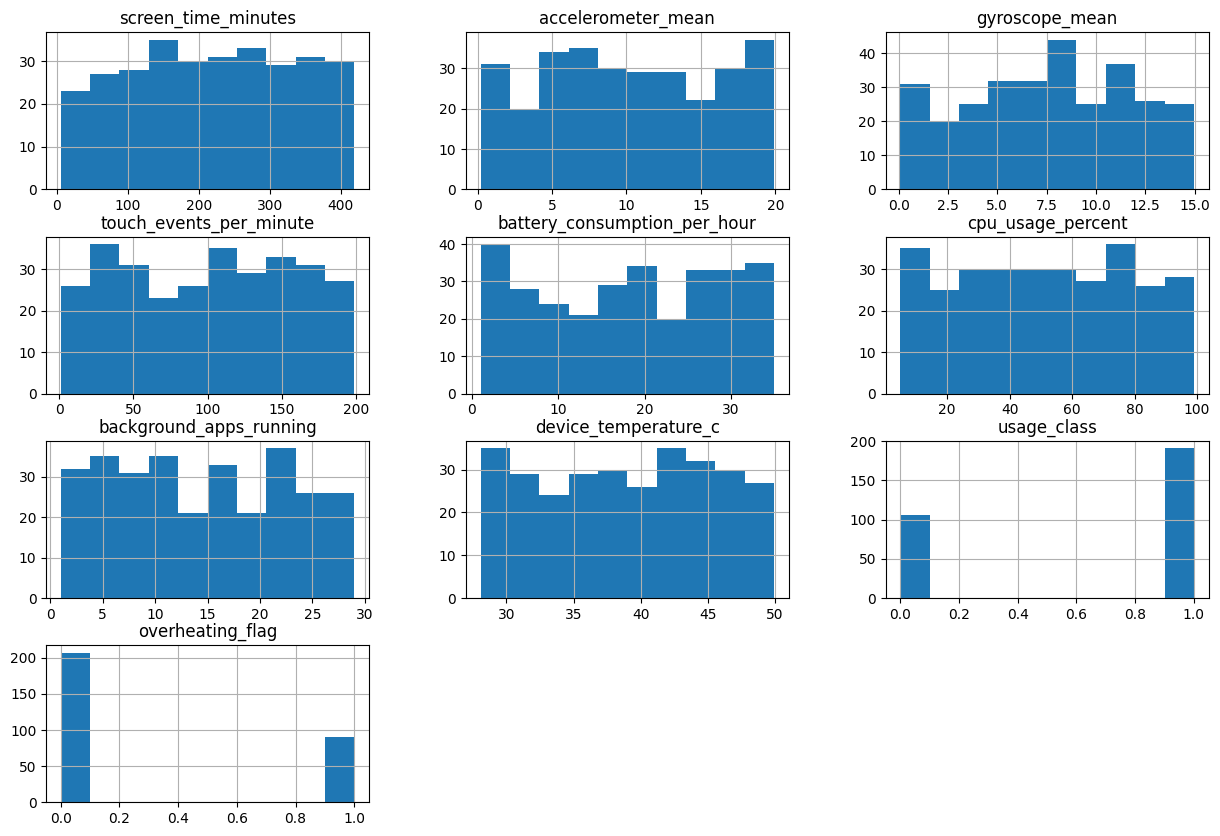

In [26]:
df.hist(figsize=(15,10))
plt.show()

In [27]:

# Outlier IQR

In [28]:

numeric_cols = df.select_dtypes(include=np.number)
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = ((numeric_cols < lower_bound) | 
                (numeric_cols > upper_bound))
print("Number of outliers using IQR:")
print(outliers_iqr.sum())

Number of outliers using IQR:
screen_time_minutes             0
accelerometer_mean              0
gyroscope_mean                  0
touch_events_per_minute         0
battery_consumption_per_hour    0
cpu_usage_percent               0
background_apps_running         0
device_temperature_c            0
usage_class                     0
overheating_flag                0
dtype: int64


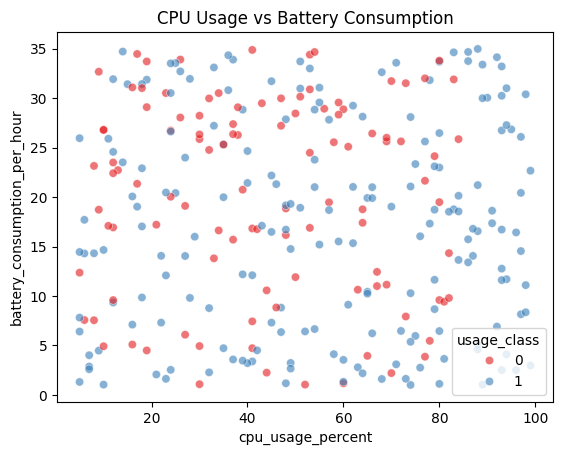

In [29]:
sns.scatterplot(x="cpu_usage_percent",
                y="battery_consumption_per_hour",
                hue="usage_class",
                data=df,
                palette="Set1",
                alpha=0.6)
plt.title("CPU Usage vs Battery Consumption")
plt.show()

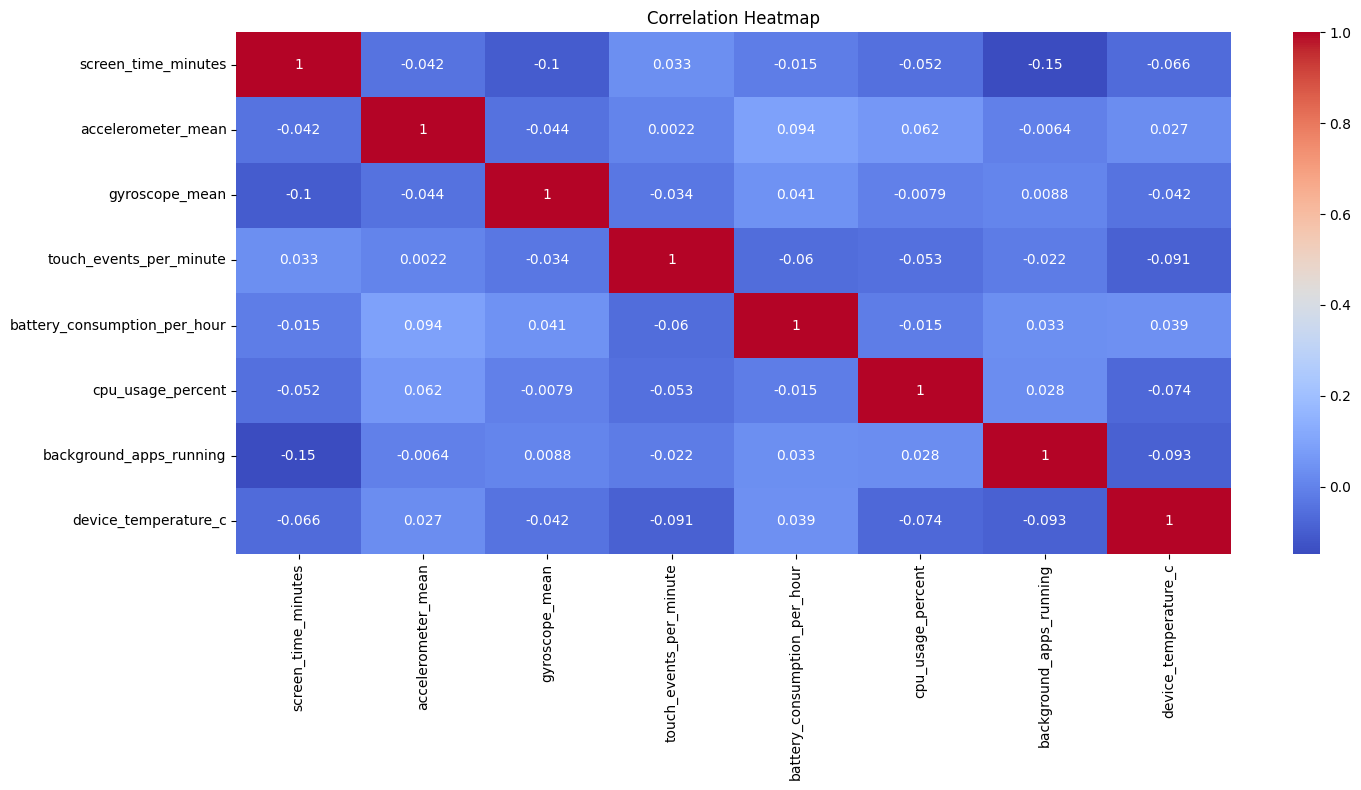

In [30]:
features = df[SENSOR_COLS]   
plt.figure(figsize=(15, 8))
sns.heatmap(features.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

<module 'matplotlib.pyplot' from 'C:\\Users\\Shivansh\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\matplotlib\\pyplot.py'>

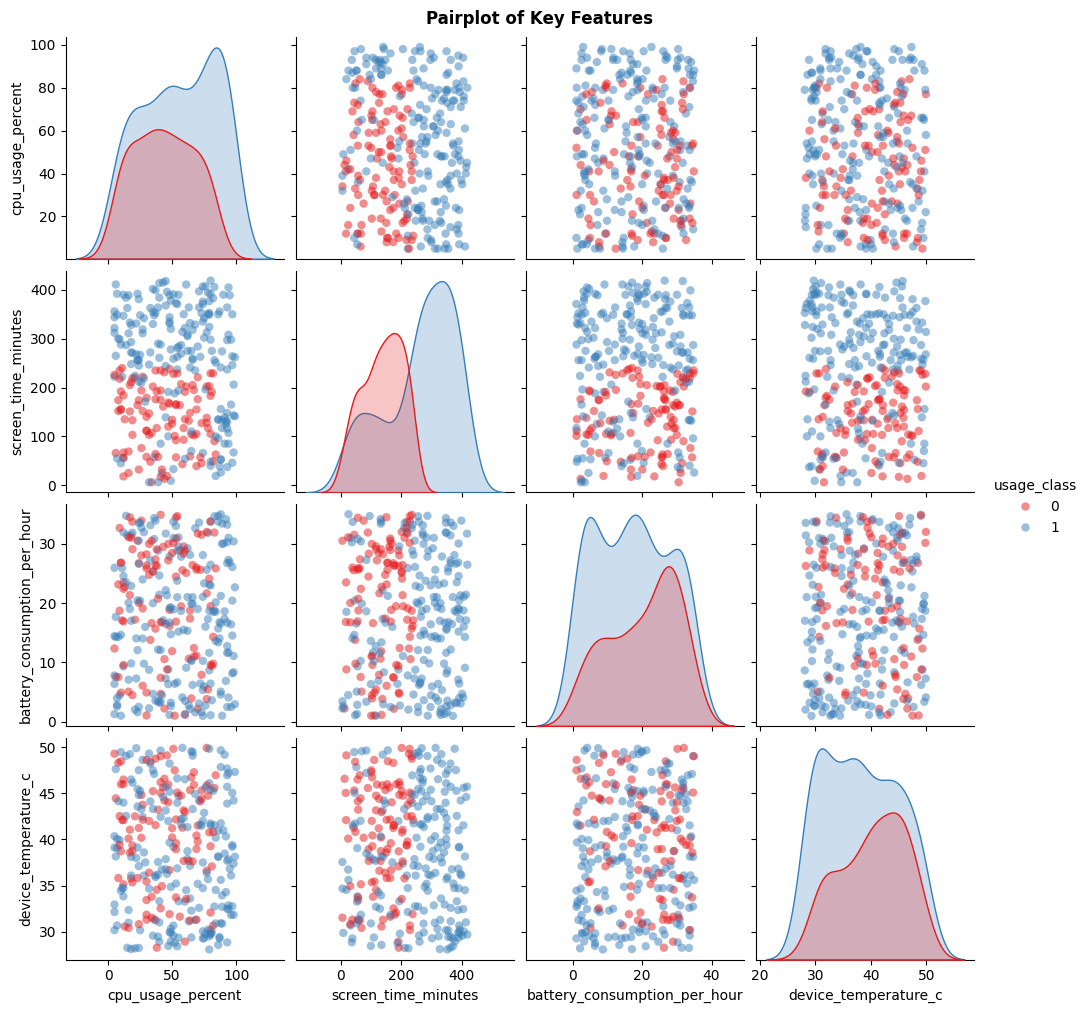

In [31]:
top_features = ['cpu_usage_percent', 'screen_time_minutes',
                'battery_consumption_per_hour', 'device_temperature_c', 'usage_class']
sns.pairplot(df[top_features], hue='usage_class',
             palette='Set1', plot_kws={'alpha': 0.5, 'edgecolor': 'none'})
plt.suptitle('Pairplot of Key Features', y=1.01, fontsize=12, fontweight='bold')
plt

In [32]:
def content_type(row):
    if row["touch_events_per_minute"] > 150:
        return "Short_Videos"
    elif row["cpu_usage_percent"] > 80:
        return "Gaming"
    elif row["screen_time_minutes"] > 250:
        return "Social_Media"
    else:
        return "Educational"

df["content_type"] = df.apply(content_type, axis=1)
def disease(row):
    if row["screen_time_minutes"] > 300:
        return "Eye_Strain"
    elif row["cpu_usage_percent"] > 85 and row["touch_events_per_minute"] > 150:
        return "Addiction"
    elif row["device_temperature_c"] > 44:
        return "Fatigue"
    else:
        return "Normal"

df["disease_risk"] = df.apply(disease, axis=1)
def parental_lock(row):
    if row["Age_Group"] == "Teen" and row["screen_time_minutes"] > 240:
        return 1
    elif row["Age_Group"] == "Teen" and row["content_type"] == "Short_Videos":
        return 1
    else:
        return 0

df["parental_lock"] = df.apply(parental_lock, axis=1)


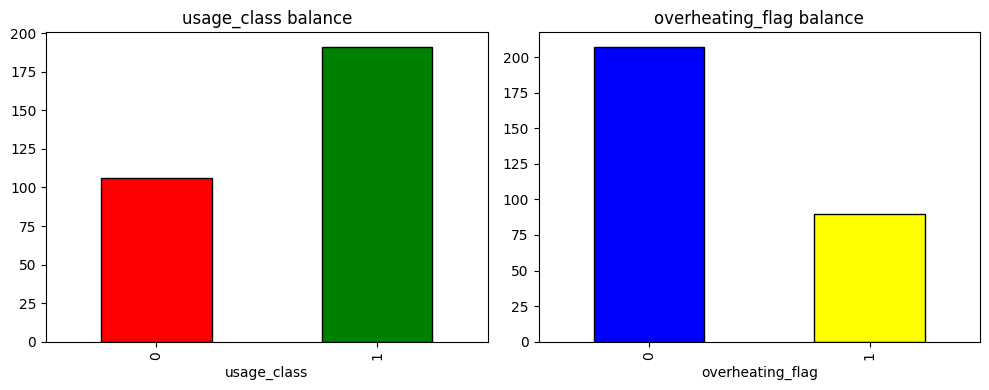

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["usage_class"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["red", "green"], edgecolor="black")
axes[0].set_title("usage_class balance")
df["overheating_flag"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["blue", "yellow"], edgecolor="black")
axes[1].set_title("overheating_flag balance")
plt.tight_layout()
plt.show()

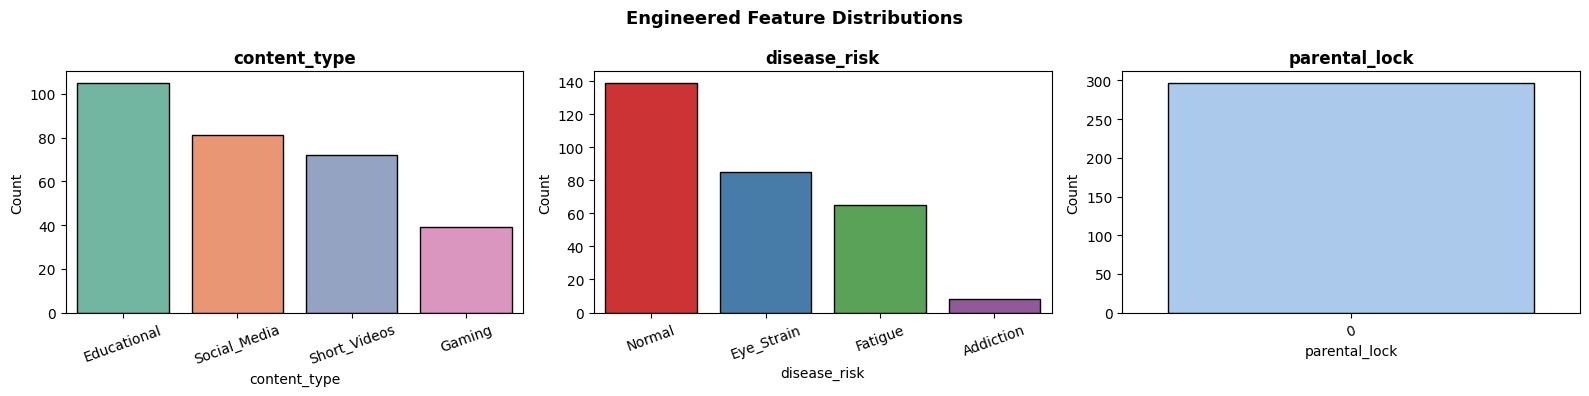

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes,
                           ['content_type', 'disease_risk', 'parental_lock'],
                           ['Set2', 'Set1', 'pastel']):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette=color, ax=ax, edgecolor='black')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Engineered Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
df.to_csv("AI AND ML PBL PHASE 2 DATASET.csv", index=False)
